<a href="https://colab.research.google.com/github/peterbabulik/QuantumWalker/blob/main/QNN_QCA_Scanner2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QCA Universe Scanner: The Search for Stable Structures ("Rocks")

This repository contains the code and results of a scientific experiment designed to map the landscape of **stable fixed points** within a Quantum Cellular Automaton (QCA). It serves as a companion experiment to the "Spaceship Discovery" project.

The central scientific question is: **Is the "Law of Complexity" universal, or is it an artifact of the specific problem we ask the system to solve?**

To answer this, we tasked our AI-driven discovery engine with a new mission: instead of searching for dynamic, moving "spaceships," we commanded it to find static, stable "rocks"—states that do not change over time.

## The Experiment: A New Question for the Same Universe

The experimental setup is nearly identical to the "Spaceship Scanner." We use the same QNN-based generative model and the same underlying QCA with identical "laws of physics." The only change is the **scientific question**, which is embedded in the cost function.

### The Hybrid Learning Loop

1.  **The QNN (Generator):** Proposes a candidate initial state `S₀`.
2.  **The QCA (Universe):** The state `S₀` is evolved for a set number of steps (`T`) to get `S_final`.
3.  **The "Rock" Critic (New Cost Function):** A classical algorithm calculates a new cost:
    -   It first disqualifies trivial states (all-0s or all-1s).
    -   The cost is then defined as the difference between the final state and the initial state: `cost = hamming_distance(S_final, S₀)`.
    -   A perfect "rock" is a state that does not change, resulting in a `cost = 0`.
4.  **The Optimizer:** A classical optimizer guides the QNN to find states that minimize this stability cost.

## The Results: A Different Law of Complexity

The results of this scan were dramatically different from the search for "spaceships," providing a clear answer to our primary scientific question.

<!-- IMPORTANT: Replace with the URL to your "Rock" plot image! -->

### Key Findings:

When we ask the universe about stability instead of dynamics, a completely different "Law of Complexity" emerges.

| N (System Size) | # of "Rock" Families (Stable) | # of "Spaceship" Families (Dynamic) |
|:---:|:---:|:---:|
| 4 | 2 | 2 |
| 5 | 3 | 2 |
| 6 | 6 | 2 |
| 7 | 8 | 3 |
| 8 | 14 | 5 |
| 9 | 19 | 6 |

The complexity curve for stable "rocks" is a smooth, accelerating, **exponential-like curve**. This is in stark contrast to the jagged, hesitant curve found for dynamic "spaceships."

### The Grand Conclusion

The universe's potential for complexity is not a single, fixed property. **The complexity you discover is a direct function of the question you ask.**

1.  **Dynamic Complexity ("Spaceships"):** The search for dynamic, periodic patterns is a highly constrained problem. The system's ability to support these solutions appears to be governed by subtle rules of symmetry and number theory related to the system size `N`.
2.  **Static Complexity ("Rocks"):** The search for stable fixed points is a much less constrained problem. The number of possible stable configurations grows rapidly and smoothly with the size of the system.

This project successfully demonstrates that by changing the "lens" through which we observe a complex system (i.e., changing the cost function), we can reveal entirely different, equally valid, fundamental laws governing its behavior.

## How to Run the Code

This project is self-contained and uses a manually implemented optimizer.

### 1. Installation

Ensure you have a modern version of Qiskit installed.

```bash
pip install --upgrade qiskit qiskit-aer numpy matplotlib
```

### 2. Execution

The entire scanning experiment is contained in the single Python script.

```bash
python your_rock_scanner_script.py
```

The script will automate the process of scanning different universe sizes (`N`), finding all unique stable states, and plotting the final complexity curve. Note that the scan can be computationally intensive and may take a significant amount of time to complete.
```

In [1]:
!pip install qiskit qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 8.7 MB/s eta 0:00:00


--- QCA Universe Scanner: The Search for 'Rocks' (Stable Fixed Points) ---
Qiskit version: 2.0.2

--- Scanning for 'Rocks' in N=4, D=12, Stability Steps=4 ---

Completed scan for N=4, D=12. Found 4 unique solutions.

--- Scanning for 'Rocks' in N=5, D=12, Stability Steps=4 ---

Completed scan for N=5, D=12. Found 6 unique solutions.

--- Scanning for 'Rocks' in N=6, D=12, Stability Steps=4 ---

Completed scan for N=6, D=12. Found 10 unique solutions.

--- Scanning for 'Rocks' in N=7, D=12, Stability Steps=4 ---

Completed scan for N=7, D=12. Found 14 unique solutions.

--- Scanning for 'Rocks' in N=8, D=12, Stability Steps=4 ---

Completed scan for N=8, D=12. Found 22 unique solutions.

--- Scanning for 'Rocks' in N=9, D=12, Stability Steps=4 ---

Completed scan for N=9, D=12. Found 30 unique solutions.

--- 'ROCK' SCAN COMPLETE IN 3113.37 SECONDS ---

--- Analysis of Results: Number of Stable Structures vs. System Size ---
N = 4 (D=12): Found 4 total solutions, representing 2 unique f

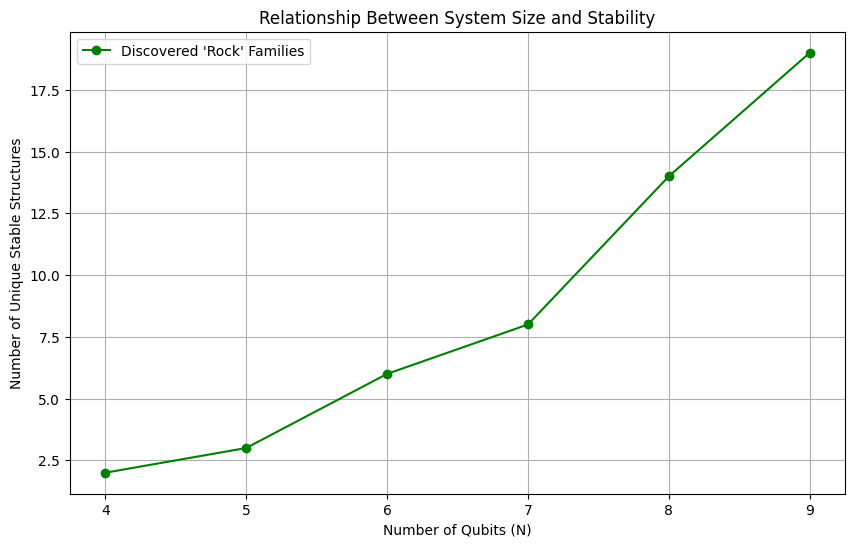

In [3]:

# ==============================================================================
#  PREAMBLE: IMPORTS AND SETUP
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import time
from typing import Dict, List, Tuple, Set

# Qiskit Imports
import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import CXGate, CZGate, SwapGate, IGate, XGate
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

print("--- QCA Universe Scanner: The Search for 'Rocks' (Stable Fixed Points) ---")
print(f"Qiskit version: {qiskit.__version__}")

# ==============================================================================
#  CORE COMPONENTS (QCA and QNN are unchanged)
# ==============================================================================

GATES = {"CX": CXGate(), "CZ": CZGate(), "SWAP": SwapGate(), "I": IGate()}
class QuantumCellularAutomaton:
    def __init__(self, num_qunodes: int, interaction_config: Dict):
        self.num_qunodes = num_qunodes
        self.interaction_config = interaction_config
        self.simulator = AerSimulator(method='statevector')
    def _get_interaction_unitary(self, t1, t2): return self.interaction_config.get(tuple(sorted((t1, t2))), GATES["I"])
    def evolve_state(self, initial_state: np.ndarray) -> np.ndarray:
        if self.num_qunodes == 0: return np.array([])
        qc = QuantumCircuit(self.num_qunodes)
        for i, bit in enumerate(initial_state):
            if bit == 1: qc.x(i)
        if self.num_qunodes > 0: qc.barrier()
        for i in range(self.num_qunodes):
            j = (i + 1) % self.num_qunodes
            op = self._get_interaction_unitary(initial_state[i], initial_state[j])
            if self.num_qunodes > 1 and op.name != 'id':
                qc.append(op, [i, j])
        sv = Statevector(qc)
        probs = sv.probabilities_dict()
        max_prob_str = max(probs, key=probs.get)
        return np.array([int(bit) for bit in max_prob_str[::-1]])

def create_generator_qnn(n_q: int, d: int) -> QuantumCircuit:
    if n_q == 0: return QuantumCircuit(0)
    theta = ParameterVector('θ', n_q * d)
    qc = QuantumCircuit(n_q)
    for i in range(d):
        for j in range(n_q): qc.ry(theta[i * n_q + j], j)
        if n_q > 1:
            for j in range(n_q - 1): qc.cz(j, j + 1)
    qc.measure_all()
    return qc

# ==============================================================================
#  THE NEW COST FUNCTION: SEARCHING FOR STABILITY
# ==============================================================================

def create_cost_function_for_stability(
    qca: QuantumCellularAutomaton,
    generator_qnn: QuantumCircuit,
    stability_steps: int
):
    """Creates a cost function that rewards states that do not change over time."""
    n_q = generator_qnn.num_qubits
    if n_q == 0: return lambda theta: (1, [])
    backend = AerSimulator()

    def cost_func(theta):
        bound_qc = generator_qnn.assign_parameters(theta)
        res = backend.run(bound_qc, shots=1, memory=True).result()
        s_init_str = res.get_memory()[0]
        s_init = np.array([int(b) for b in s_init_str[::-1]])

        activity = np.sum(s_init)
        if activity == 0 or activity == n_q: return n_q, s_init

        s_final = s_init
        for _ in range(stability_steps):
            s_final = qca.evolve_state(s_final)

        cost = np.sum(s_final != s_init)
        return cost, s_init
    return cost_func

# ==============================================================================
#  THE META-EXPERIMENT: RE-TOOLED FOR THE NEW QUESTION
# ==============================================================================

def find_solutions_for_config(
    N: int, D: int, S: int,
    max_iter: int, num_runs: int, rules: Dict
) -> Set[Tuple[int, ...]]:
    print(f"\n--- Scanning for 'Rocks' in N={N}, D={D}, Stability Steps={S} ---")

    qca_universe = QuantumCellularAutomaton(num_qunodes=N, interaction_config=rules)
    generator_qnn = create_generator_qnn(n_q=N, d=D)

    # ===================================================================
    # THE FIX IS HERE: We now correctly call the new cost function
    # ===================================================================
    cost_function = create_cost_function_for_stability(
        qca=qca_universe,
        generator_qnn=generator_qnn,
        stability_steps=S
    )

    unique_solutions_found = set()
    for i in range(num_runs):
        print(f"  Run {i+1}/{num_runs}...", end='\r')
        for _ in range(max_iter):
            params = np.random.uniform(0, 2 * np.pi, generator_qnn.num_parameters) if generator_qnn.num_parameters > 0 else []
            cost, state = cost_function(params)
            if cost == 0:
                unique_solutions_found.add(tuple(state))

    print(f"\nCompleted scan for N={N}, D={D}. Found {len(unique_solutions_found)} unique solutions.")
    return unique_solutions_found

# ==============================================================================
#  THE MAIN CONTROL SCRIPT
# ==============================================================================

if __name__ == "__main__":
    # --- Define the Scan Parameters ---
    N_range = range(4, 10)  # Scan N=4 through 9 to compare with previous results
    D_range = [12]          # Use a single deep QNN for consistency

    # We are checking for stability over 4 steps
    STABILITY_STEPS = 4

    RUNS_PER_CONFIG = 100
    ITER_PER_RUN = 500

    # --- Use the same "Laws of Physics" ---
    QCA_RULES = {
        (0, 0): IGate(),
        (1, 1): CXGate(),
        (0, 1): SwapGate()
    }

    # --- Data Collection ---
    all_results = {}
    scan_start_time = time.time()

    for n_qubits in N_range:
        for qnn_depth in D_range:
            solutions = find_solutions_for_config(
                N=n_qubits, D=qnn_depth, S=STABILITY_STEPS,
                max_iter=ITER_PER_RUN, num_runs=RUNS_PER_CONFIG, rules=QCA_RULES
            )
            all_results[(n_qubits, qnn_depth)] = solutions

    scan_end_time = time.time()
    print(f"\n--- 'ROCK' SCAN COMPLETE IN {scan_end_time - scan_start_time:.2f} SECONDS ---")

    # --- STATISTICAL ANALYSIS ---
    print("\n--- Analysis of Results: Number of Stable Structures vs. System Size ---")

    num_solutions_per_n = {}
    for (n, d), solutions in all_results.items():
        canonical_solutions = set()
        for sol in solutions:
            arr = np.array(sol)
            shifts = {tuple(np.roll(arr, i)) for i in range(len(arr))}
            canonical_solutions.add(min(shifts))
        num_solutions_per_n[n] = len(canonical_solutions)
        print(f"N = {n} (D={d}): Found {len(solutions)} total solutions, representing {len(canonical_solutions)} unique families of 'rocks'.")

    # Plot the new complexity curve
    n_values = np.array(list(num_solutions_per_n.keys()))
    solution_counts = np.array(list(num_solutions_per_n.values()))

    plt.figure(figsize=(10, 6))
    plt.plot(n_values, solution_counts, 'o-', color='green', label="Discovered 'Rock' Families")
    plt.xlabel("Number of Qubits (N)")
    plt.ylabel("Number of Unique Stable Structures")
    plt.title("Relationship Between System Size and Stability")
    plt.grid(True)
    plt.xticks(n_values)
    plt.legend()
    plt.show()